### Fixing the environment

In [ ]:
#Importing packages
import sys
sys.path.append('/home/onyxia/work/nlp_central_banks/lyna_work')
import importlib
import module
importlib.reload(module)
from module import *

In [ ]:
#Importing torch and making sure the GPU is available
import sys
print(sys.executable)  # doit afficher .../venv_gpu/bin/python

import torch
print(torch.cuda.is_available())  # doit afficher True
print(torch.cuda.get_device_name(0))  # NVIDIA A2

In [3]:
# ── Verification GPU ────────────────────────────────────
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


PyTorch  : 2.6.0+cu124
CUDA     : True
GPU      : NVIDIA A2
VRAM     : 15.7 GB


### BERTopic pipeline
#### Preprocessing the data

I import my preprocessed data.

In [4]:
# Importing the preprocessed data from the first notebook (saved in the SSP Cloud) :
fs = s3fs.S3FileSystem(
    client_kwargs={"endpoint_url": "https://minio.lab.sspcloud.fr"}
)
fs.invalidate_cache()
with fs.open("lelkamel/chunks/df_filtered.csv", "rb") as f:
    df_filtered = pd.read_csv(f)
print(f"df_filtered chargé : {df_filtered.shape}")

df_filtered chargé : (2286, 19)


Now I will compare my text's size to that of the model that interests me, to see whether it fits the context window.

I begin by retrieving the context window size of the model that I will use on the HuggingFace.

In [11]:
from transformers import AutoConfig

config = AutoConfig.from_pretrained("hugom123/bge-centralbank")
print(config.max_position_embeddings)

512


In [12]:
df_filtered["text.len"] = df_filtered["text"].apply(len)
df_filtered["text.len"].describe()

count      2286.000000
mean      20002.870954
std       11961.596277
min        1314.000000
25%       11670.250000
50%       17653.500000
75%       25741.750000
max      122759.000000
Name: text.len, dtype: float64

My text clearly does not fit the context window of this model. To resolve this, I decide to chunk it. This strategy will also enable me to retrive topics within speeches. 

In [ ]:
# I do the chunking, thanks to a function I built, available in the module section
#if torch.cuda.is_available():
#    spacy.prefer_gpu()  # utilise GPU si CuPy dispo, sinon CPU sans erreur

#nlp = spacy.load("en_core_web_sm")

#tokenizer = AutoTokenizer.from_pretrained("hugom123/bge-centralbank")

#df_chunks = process_corpus(df_filtered)

#print(f"\nDiscours        : {len(df_filtered)}")
#print(f"Chunks          : {len(df_chunks)}")
#print(f"Chunks/discours : {len(df_chunks)/len(df_filtered):.1f}")
#print(f"\nTaille chunks (mots) :")
#print(df_chunks['n_words'].describe().round(0))
#print(f"\nChunks < 50 mots : {(df_chunks['n_words'] < 50).sum()}")
#I save it 
#df_chunks.to_csv("s3://lelkamel/chunks/df_chunks_all.csv", index=False)


In [5]:
#To save computing time, I import here the chunk database, obtained and saved in the previous code cell.
with fs.open("lelkamel/chunks/df_chunks_all.csv", "rb") as f:
    df_chunks_all = pd.read_csv(f)

print(df_chunks_all.columns.tolist())
print(f"\nNombre de discours uniques : {df_chunks_all['doc_id'].nunique()}")
print(f"Chunks par discours (moy.) : {len(df_chunks_all)/df_chunks_all['doc_id'].nunique():.1f}")
print(f"\nAnnées : {df_chunks_all['Year'].min()} - {df_chunks_all['Year'].max()}")

['doc_id', 'chunk_id', 'CentralBank', 'Date', 'Year', 'Authorname', 'Role', 'Source', 'chunk_text', 'n_words']

Nombre de discours uniques : 2286
Chunks par discours (moy.) : 10.5

Années : 2001 - 2023


### I now create a BERTopic object, fit and transform

To create my `topic_model`, I start by creating a `BERTopic` object and define some parameters. 
- I begin by computing the embeddings of my chunks with `hugom123/bge-centralbank` and saving it in the onyxia cloud. 
- Secondly, I define my vectoriser model in order to remove common english stopwords as well as other economic and institutional stopwords to retrive meaningful topics. 
- Then, I do not change the default parameters of the clutering model at start (`hdbscan_model`), nor the dimension reduction model (`umap_model`). 
- Finally, I use the fit methode to fit the topic model to the corpus.

In [ ]:
# In this cell, I compute the embedding for all chunks
 #I begin by importing chunks, then import the model, then apply it on my data, then save it.   


#docs = df_chunks_all['chunk_text'].tolist()
#print(f"Nombre de chunks : {len(docs)}")
#print("\nChargement du modèle...")
#embedding_model = SentenceTransformer("hugom123/bge-centralbank")
#print("Calcul des embeddings...")
#embeddings = embedding_model.encode(
#    docs,
#    batch_size=64,
#    show_progress_bar=True,
#    device="cuda" if torch.cuda.is_available() else "cpu"
#)
#print(f"Embeddings shape : {embeddings.shape}")
#print("\nSauvegarde embeddings sur S3...")
#with fs.open("lelkamel/chunks/embeddings_all.npy", "wb") as f:
#    np.save(f, embeddings)
#print("Embeddings sauvegardés : s3://lelkamel/chunks/embeddings_all.npy")

In [6]:
#To save computing time, I import here the embeddings obtained and saved in the previous code cell.
with fs.open("lelkamel/chunks/embeddings_all.npy", "rb") as f:
    embeddings = np.load(f)

print(f"Embeddings chargés : {embeddings.shape}")

Embeddings chargés : (23913, 1024)


In [7]:
vectorizer_model = CountVectorizer(
    stop_words= get_stopwords(),
    ngram_range=(1, 2),
    min_df=2,
    lowercase=True
)

In the next cell, I run the Bertopic model. I finetune it so that I control more the granularity of the model. I select `n_neighbors` and `min_cluster_size` to be equal to 50. This enables me to get 108 topics with enough granularity. For example, I have two climate topics, one which focuses on financial risks from climate, the other focuses on green transition and ESG. These are not exactly the same and it is interesting to see these differences (see below for this example).

In [8]:
docs = df_chunks_all['chunk_text'].tolist()

In [ ]:


RANDOM_SEED = 42
default_umap_parameters = {
    "n_neighbors": 50,
    "n_components": 5,
    "min_dist": 0.0,
    "metric": "cosine",
}
hdbscan_model = HDBSCAN(
    min_cluster_size=50,      # plus petit = plus de topics
    min_samples=5,            # moins strict = moins d'outliers
    metric='euclidean',
    cluster_selection_method='leaf',  # 'leaf' crée plus de petits clusters
    prediction_data=True
)

topic_model = BERTopic(
    language="english",
    embedding_model="hugom123/bge-centralbank",
    vectorizer_model=vectorizer_model,
    umap_model=UMAP(**default_umap_parameters, random_state=42),
    hdbscan_model=hdbscan_model,
    min_topic_size=20,
   nr_topics=None,
    calculate_probabilities=True,
   verbose=True,
)

topics, probs = topic_model.fit_transform(
    documents=docs,
    embeddings=embeddings
)

df_chunks_all['topic']      = topics
df_chunks_all['topic_prob'] = probs.max(axis=1) if probs.ndim > 1 else probs

print(f"\nNombre de topics : {topic_model.get_topic_info().shape[0] - 1}")

In [9]:
topics, probabilities = topic_model.transform(documents=docs, embeddings=embeddings)

2026-04-29 19:35:01,583 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-04-29 19:35:01,757 - BERTopic - Dimensionality - Completed ✓
2026-04-29 19:35:01,758 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-04-29 19:35:02,886 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2026-04-29 19:35:18,080 - BERTopic - Probabilities - Completed ✓
2026-04-29 19:35:18,084 - BERTopic - Cluster - Completed ✓


In [10]:
topic_info = topic_model.get_topic_info()
topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,10578,-1_credit_term_risks_us,"[credit, term, risks, us, see, prices, banking...","[Fortunately, this scenario has so far not com..."
1,0,416,0_liquidity_operations_refinancing_refinancing...,"[liquidity, operations, refinancing, refinanci...",[We have decided on three-year refinancing ope...
2,1,409,1_fiscal_pact_countries_public,"[fiscal, pact, countries, public, union, struc...","[Nonetheless, further reforms in the fiscal ar..."
3,2,362,2_supervisory_supervision_eu_banking,"[supervisory, supervision, eu, banking, ssm, e...","[In addition, a new idea of reform contracts w..."
4,3,359,3_medium_medium term_outlook_term,"[medium, medium term, outlook, term, developme...","[Turning to the price developments, annual HIC..."
...,...,...,...,...,...
105,104,52,104_flows_emerging_emes_inflows,"[flows, emerging, emes, inflows, push, pull fa...",[II. Growing challenges in the Current IMFS Ch...
106,105,52,105_productivity_1995_per_output,"[productivity, 1995, per, output, labor produc...",[Different methods of data construction will y...
107,106,52,106_loans_liquidity_lending_credit,"[loans, liquidity, lending, credit, commercial...",[BIS central bankers speeches 3 recognition th...
108,107,51,107_spending_housing_sales_construction,"[spending, housing, sales, construction, house...","[Hence, with production running well below sal..."


The BERTopic model identifies **109 topics** from the corpus of 30,401 chunks. Several of them are immediately interpretable and consistent with what one would expect from central bank communication over the 2001--2023 period:

- **Topic 15 — Housing & Mortgages** (`mortgage, mortgages, subprime, borrowers`):  not surprising given that the 2008 financial crisis shed light on the interaction between the housing market and financial stability; we will examine whether this topic is predominantly concentrated in the post-2008 period.

- **Topic 41 — Digital Money & Payments** (`digital, money, payments, payment`): distinct from the crypto topic, this cluster captures the debate around Central Bank Digital Currencies (CBDCs) and the modernisation of payment systems.

- **Topic 38 — Inequality & Wealth** (`wealth, income, inequality, families`): a particularly interesting topic, as distributional concerns are not historically part of the core central bank mandate. Its presence in the corpus warrants further investigation into its temporal distribution.

- **Topics 77 & 94 — Climate Change** (`climate change, risks, green, transition`): consistent with the findings of Campiglio et al. (2025); BERTopic identifies two distinct climate-related clusters — one centred on climate as a **financial risk** (stress testing, TCFD disclosures) and one on the **green transition** agenda (ESG, net zero, carbon) — which confirms and refines their dictionary-based approach.

- **Topic 90 — Crypto & Stablecoins** (`crypto, stablecoins, stablecoin, bitcoin`): an emerging topic reflecting the growing attention of central bankers to decentralised finance and the regulatory challenges it poses.

- **Topic 91 — 2008 Financial Crisis** (`aig, credit, treasury, institutions`): this topic clearly captures the acute phase of the 2008 crisis, referencing key institutional actors (AIG, Treasury) and emergency interventions.

However, **Topic -1 accounts for 10,578 chunks, representing 34.8% of the corpus** — a substantial share of documents that HDBSCAN was unable to assign to any cluster. This is a known limitation of density-based clustering: documents that do not belong to a sufficiently dense region of the embedding space are labelled as outliers. 

To address this, I apply the `reduce_outliers` method with the **embedding strategy**. This approach assigns each outlier chunk to the topic whose centroid is closest in the embedding space, using cosine similarity. 

In [ ]:
new_topics = topic_model.reduce_outliers(
    documents=docs,
    topics=topics,
    probabilities=probs,
    embeddings=embeddings,
    strategy="embeddings",
    threshold=0.0
)

# Mettre à jour le modèle
topic_model.update_topics(
    docs,
    topics=new_topics,
    vectorizer_model=vectorizer_model
)

df_chunks_all['topic'] = new_topics
print(f"Outliers restants : {(pd.Series(new_topics) == -1).sum()}")
print("\n=== Top 30 topics ===")
print(topic_model.get_topic_info().head(30))
print(topic_model.get_topic_info().head(30))

with fs.open("lelkamel/chunks/df_chunks_with_topics.csv", "wb") as f:
    df_chunks_all.to_csv(f, index=False)
print("df_chunks_with_topics sauvegardé sur S3 !")

I don't have any outlier anymore ! See the next notebook for more visualisation.

In [ ]:
#I save the model
fs = s3fs.S3FileSystem(
    client_kwargs={"endpoint_url": "https://minio.lab.sspcloud.fr"}
)

local_dir = "./topic_model_v2"
s3_dir = "lelkamel/chunks/topic_model_v2"

for filename in os.listdir(local_dir):
    local_path = os.path.join(local_dir, filename)
    s3_path = f"{s3_dir}/{filename}"
    fs.put(local_path, s3_path)
    print(f"Uploaded : {filename}")

print("Modèle sauvegardé sur S3 !")

Uploaded : ctfidf.safetensors
Uploaded : config.json
Uploaded : topics.json
Uploaded : topic_embeddings.safetensors
Uploaded : ctfidf_config.json
Modèle sauvegardé sur S3 !


In [9]:
# Uploading the model
local_dir = "./topic_model_v2"
s3_dir = "lelkamel/chunks/topic_model_v2"

os.makedirs(local_dir, exist_ok=True)

for filename in fs.ls(s3_dir):
    s3_path = filename
    local_path = os.path.join(local_dir, os.path.basename(filename))
    fs.get(s3_path, local_path)
    print(f"Downloaded : {os.path.basename(filename)}")

# Charger le modèle
topic_model = BERTopic.load(
    local_dir,
    embedding_model="hugom123/bge-centralbank"
)
print(f"Modèle chargé : {topic_model.get_topic_info().shape[0]-1} topics")

Downloaded : config.json
Downloaded : ctfidf.safetensors
Downloaded : ctfidf_config.json
Downloaded : topic_embeddings.safetensors
Downloaded : topics.json


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 4669.87it/s]


Modèle chargé : 108 topics


### Visualisation of the results

In [10]:
setup_plotly()

nbformat : 5.10.4


In [13]:
fig = topic_model.visualize_hierarchy()



In [14]:
# Sauvegarder en HTML puis convertir manuellement
fig.write_html("/home/onyxia/work/nlp_central_banks/lyna_work/figures/hierarchy.html")
print("HTML sauvegardé — ouvre le fichier dans le navigateur et fais Ctrl+P → Enregistrer en PDF")

HTML sauvegardé — ouvre le fichier dans le navigateur et fais Ctrl+P → Enregistrer en PDF


You can access the dendogram here : https://nbviewer.org/github/lelkamel/nlp_central_banks/blob/main/lyna_work/figures/hierarchy.html

### Agregation

Now, I will manually merge topics. The hierarchical clustering visualization (see Figure above) and pairwise cosine 
similarities between topic embeddings guide the merging decisions. I adopt a conservative approach: topics are only merged when (i) their cosine similarity exceeds 0.7 and (ii) they are substantively equivalent from an economic standpoint. When two topics are semantically close but economically distinct, I keep them separate.

A first set of merges concerns **duplicate topics** — topics that capture the same concept but in slightly different vocabularies, typically due to institutional differences across central banks. For instance, Topics 24 (`labor_unemployment_workers`) and 25 (`labour_wage_unemployment`) both describe labour market conditions but in American and British English respectively (cosine similarity: 0.909). Similarly, Topics 0, 20 and 21 all relate to liquidity provision and are merged into a single "Monetary Operations & Liquidity" topic (similarity: 0.745).

Another example of a second set of merges concerns **thematically related topics** on unconventional monetary policy. Topics 29 (`reserves_balance sheet`), 42 (`securities_purchase_treasury`) and 73 (`qe_yields_quantitative easing`) all capture the implementation of Quantitative Easing — the large-scale asset purchase programmes introduced by central banks in the aftermath of the 2008 crisis — and are merged accordingly. Two related topics are however kept separate for analytical reasons. Topic 57 (`yields_yield_term_bond`) captures the *market consequences* of QE — yield compression and term premium dynamics — rather than the policy instrument itself, and thus represents the transmission channel of unconventional monetary policy. Topic 74 (`guidance_forward guidance_forward_expectations`) captures forward guidance, a conceptually distinctunconventional tool that operates through the management of expectations about future interest rates rather than through balance sheet expansion. Tracking these three topics separately allows us to distinguish between the *implementation* ofunconventional policies, their *market transmission*, and their *communication* dimension — a distinction that will prove useful in the dynamic topic modeling analysis.

I detail more the merging choices in te appendix of my paper. To see the analysis at the agregate level, skip this part !

In [ ]:
#I build this function which can be found in the module which enable me to see two-by-two cosine similarity
check_similarity([
    [94, 77],  # Theory
], topic_model)


  Topic 94 : 94_climate_green_climate change_transition
  Topic 77 : 77_climate_climate change_risks_climate related

  ✅ Topic 94 vs Topic 77 : 0.905


In [11]:
# Merge all topics
topic_model.merge_topics(docs, [
    [27, 7, 45, 87, 80, 48],          # European union and single market integration
    [14, 108, 6],                       # European governance & integration
    [62, 85],                           # Financial market integration & payments
    [94, 77],                           # Climate change
    [78, 52, 41, 90],                   # Digital currency & payments
    [61, 44, 79],                       # Social & inclusion
    [63, 71],                           # Community development finance
    [88, 56, 37, 23, 36, 58, 10],      # Banking regulation & supervision
    [21, 91, 106, 20],                  # Crisis lending & emergency liquidity
    [81, 16],                           # Resolution & bail-in
    [69, 89, 5],                        # Macroprudential & financial stability
    [83, 99, 101, 76, 72],             # Global governance & globalization
    [22, 104, 95],                      # Global imbalances & capital flows
    [92, 82],                           # Asia & emerging markets
    [31, 8],                            # Fiscal policy & public finance
    [103, 4, 32],                       # Structural reforms
    [24, 25, 105, 53],                  # Labour market & productivity
    [38, 70],                           # Household concerns & inequality
    [40, 50, 15],                       # Housing market & mortgage credit
    [35, 26],                           # Energy & commodity prices
    [97, 12],                           # Asset prices & bubbles
    [84, 60, 51, 107, 98, 9, 34, 3],   # Macroeconomic outlook
    [29, 42, 73],                       # QE & asset purchases
    [64, 96],                           # Strategy & longer-run framework
    [54, 39, 49],                       # Historical & ceremonial
    [66, 28],                           # Communication & transparency
    [75, 100, 33, 11, 43, 102, 65, 67] # Theoretical & technical
])

In [ ]:
df_chunks_all['topic'] = topic_model.topics_

print(f"Topics after merge : {topic_model.get_topic_info().shape[0] - 1}")
print(topic_model.get_topic_info()[['Topic', 'Count', 'Name']].to_string())

In [14]:
topic_names = {
    0:  "Macroeconomic Outlook & Assessment",        # prices_demand_outlook_recovery
    1:  "Banking Regulation & Supervision",           # basel_regulatory_banking_supervision
    2:  "Theoretical & Technical Speeches",           # expectations_target_term_uncertainty
    3:  "European Integration & Single Market",       # union_countries_europe_single
    4:  "Crisis Lending & Emergency Liquidity",       # liquidity_credit_funding_funds
    5:  "European Governance & Institutional",        # integration_union_europe_ecbs
    6:  "Labour Market & Employment",                 # productivity_labor_unemployment_workers
    7:  "Structural Reforms",                         # labour_reforms_productivity_structural
    8:  "Globalization & Trade",                      # trade_countries_globalisation_exchange
    9:  "Macroprudential & Financial Stability",      # macroprudential_stress_macro_prudential
    10: "Housing Market & Mortgage Credit",           # mortgage_housing_mortgages_house
    11: "Historical & Ceremonial Speeches",           # money_great_century_economics
    12: "Quantitative Easing & Asset Purchases",      # reserves_securities_balance_balance sheet
    13: "Digital Finance, Payments & Crypto",         # payments_payment_digital_money
    14: "Global Imbalances & Capital Flows",          # foreign_account_flows_dollar
    15: "ECB Monetary Operations & Liquidity",        # liquidity_operations_credit_refinancing
    16: "Resolution & Bank Failure",                  # resolution_creditors_firms_banking
    17: "Financial Crises",                           # credit_crises_finance_sector
    18: "European Fiscal Framework (SGP)",            # fiscal_countries_pact_public
    19: "Banking Supervision (SSM/EU)",               # supervisory_supervision_banking_eu
    20: "Longer-Run Strategy & Fed Framework",        # funds_employment_longer_maximum
    21: "Asset Prices & Bubbles",                     # prices_bubble_bubbles_investors
    22: "Energy & Commodity Prices",                  # oil_prices_energy_gas
    23: "Fiscal Policy & Public Finance",             # budget_fiscal_spending_tax
    24: "Communication & Transparency",               # communication_transparency_public_decisions
    25: "Social Outreach & Financial Inclusion",      # education_students_women_school
    26: "Household Concerns & Inequality",            # income_wealth_households_inequality
    27: "Derivatives & Counterparty Risk",            # derivatives_credit_hedge_counterparty
    28: "Banking Union & Resolution Framework",       # banking_union_banking union_resolution
    29: "R-star & Equilibrium Real Rate",             # real_equilibrium_low_funds
    30: "Climate Change",                             # climate_climate change_transition_change
    31: "Bank Profitability",                         # profitability_banking_sector_banking sector
    32: "Credit Risk Management",                     # management_credit_risks_institutions
    33: "Financial Market Integration",               # integration_sepa_securities_bond
    34: "Community Development Finance",              # businesses_development_business_credit
    35: "Central Bank Independence & Governance",     # independence_decisions_mpc_members
    36: "Bond Markets & Yield Compression",           # yields_term_yield_bond
    37: "Asia & Emerging Markets",                    # asian_asia_trade_emerging
    38: "Forward Guidance",                           # guidance_forward guidance_forward_expectations
    39: "Community Banking (Fed)",                    # banking_rural_local_bankers
    40: "Statistics & Data Methodology",              # statistics_data_statistical_information
    41: "Shadow Banking",                             # shadow_shadow banking_banking_sector
    42: "Insurance & Solvency II",                    # insurance_insurers_solvency_solvency ii
    43: "LIBOR Transition"                            # libor_sonia_transition_sofr
}

# Apply to dataframe
df_chunks_all['topic_name'] = df_chunks_all['topic'].map(topic_names)

# Verify
print(df_chunks_all.groupby(['topic', 'topic_name']).size()
      .reset_index(name='count')
      .to_string())

# Save updated dataframe
with fs.open("lelkamel/chunks/df_chunks_final_topics.csv", "wb") as f:
    df_chunks_all.to_csv(f, index=False)
print("Saved !")

    topic                              topic_name  count
0       0      Macroeconomic Outlook & Assessment   2521
1       1        Banking Regulation & Supervision   1979
2       2        Theoretical & Technical Speeches   1526
3       3    European Integration & Single Market   1521
4       4    Crisis Lending & Emergency Liquidity   1154
5       5     European Governance & Institutional   1084
6       6              Labour Market & Employment    982
7       7                      Structural Reforms    759
8       8                   Globalization & Trade    738
9       9   Macroprudential & Financial Stability    706
10     10        Housing Market & Mortgage Credit    650
11     11        Historical & Ceremonial Speeches    621
12     12   Quantitative Easing & Asset Purchases    575
13     13      Digital Finance, Payments & Crypto    572
14     14       Global Imbalances & Capital Flows    508
15     15     ECB Monetary Operations & Liquidity    497
16     16               Resolut

In [19]:
# Save df_chunks_all with final topics
with fs.open("lelkamel/chunks/df_chunks_final_topics.csv", "wb") as f:
    df_chunks_all.to_csv(f, index=False)
print(f"df_chunks_final_topics sauvegardé : {df_chunks_all.shape}")

df_chunks_final_topics sauvegardé : (23913, 12)


### Visualisation

##### Emerging topics of central bank policy over time

In [20]:
topic_names = {
    0:  "Macroeconomic Outlook",
    1:  "Banking Regulation",
    2:  "Theoretical & Technical",
    3:  "European Integration",
    4:  "Crisis Liquidity",
    5:  "European Governance",
    6:  "Labour Market",
    7:  "Structural Reforms",
    8:  "Globalization & Trade",
    9:  "Macroprudential",
    10: "Housing & Mortgages",
    11: "Historical & Ceremonial",
    12: "Quantitative Easing",
    13: "Digital Finance & Crypto",
    14: "Global Imbalances",
    15: "ECB Monetary Operations",
    16: "Resolution & Bail-in",
    17: "Financial Crises",
    18: "European Fiscal Rules",
    19: "Banking Supervision",
    20: "Fed Long-Run Framework",
    21: "Asset Prices & Bubbles",
    22: "Energy & Commodities",
    23: "Fiscal Policy",
    24: "CB Communication",
    25: "Social Outreach",
    26: "Inequality & Households",
    27: "Derivatives & OTC",
    28: "Banking Union",
    29: "R-star",
    30: "Climate Change",
    31: "Bank Profitability",
    32: "Credit Risk",
    33: "Financial Market Integration",
    34: "Community Development",
    35: "CB Independence",
    36: "Bond Markets",
    37: "Asia & Emerging Markets",
    38: "Forward Guidance",
    39: "Community Banking",
    40: "Statistics & Data",
    41: "Shadow Banking",
    42: "Insurance & Solvency II",
    43: "LIBOR Transition"
}

df_chunks_all['topic_name_short'] = df_chunks_all['topic'].map(topic_names)

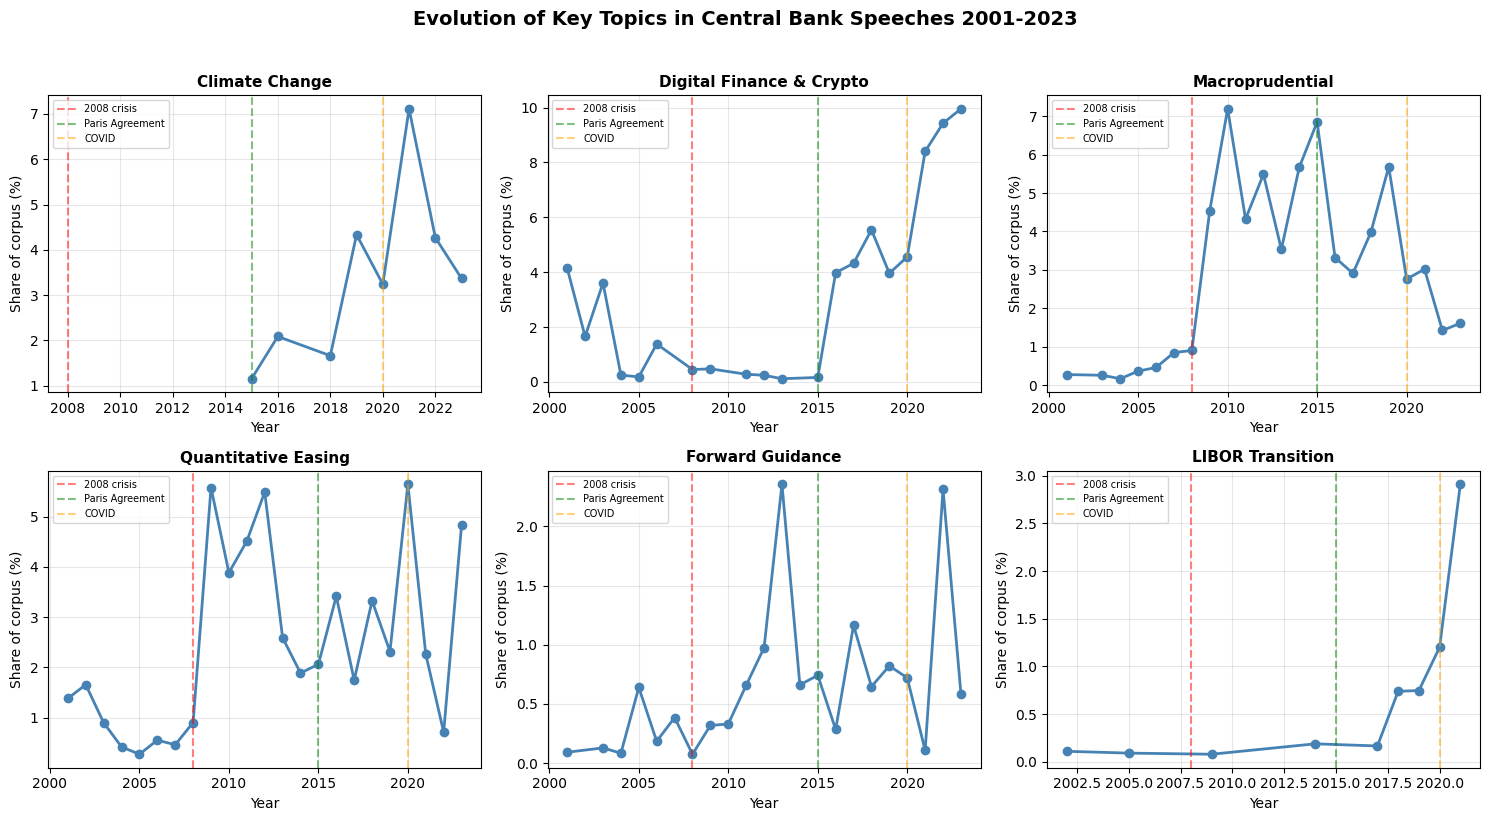

Saved !


In [21]:
# Compute share of each topic per year
yearly = (
    df_chunks_all.groupby(['Year', 'topic', 'topic_name_short'])
    .size()
    .reset_index(name='count')
)
yearly_total = df_chunks_all.groupby('Year').size().reset_index(name='total')
yearly = yearly.merge(yearly_total, on='Year')
yearly['share'] = yearly['count'] / yearly['total'] * 100

# Plot emerging topics
emerging_topics = [30, 13, 9, 12, 38, 43]  # climate, digital, macroprudential, QE, forward guidance, LIBOR

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, topic_id in enumerate(emerging_topics):
    data = yearly[yearly['topic'] == topic_id]
    name = topic_names[topic_id]
    axes[i].plot(data['Year'], data['share'], marker='o', linewidth=2, color='steelblue')
    axes[i].set_title(name, fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Share of corpus (%)')
    axes[i].axvline(x=2008, color='red', linestyle='--', alpha=0.5, label='2008 crisis')
    axes[i].axvline(x=2015, color='green', linestyle='--', alpha=0.5, label='Paris Agreement')
    axes[i].axvline(x=2020, color='orange', linestyle='--', alpha=0.5, label='COVID')
    axes[i].legend(fontsize=7)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Evolution of Key Topics in Central Bank Speeches 2001-2023', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/home/onyxia/work/nlp_central_banks/lyna_work/figures/topics_over_time_emerging.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved !")

#####  Difference between central banks

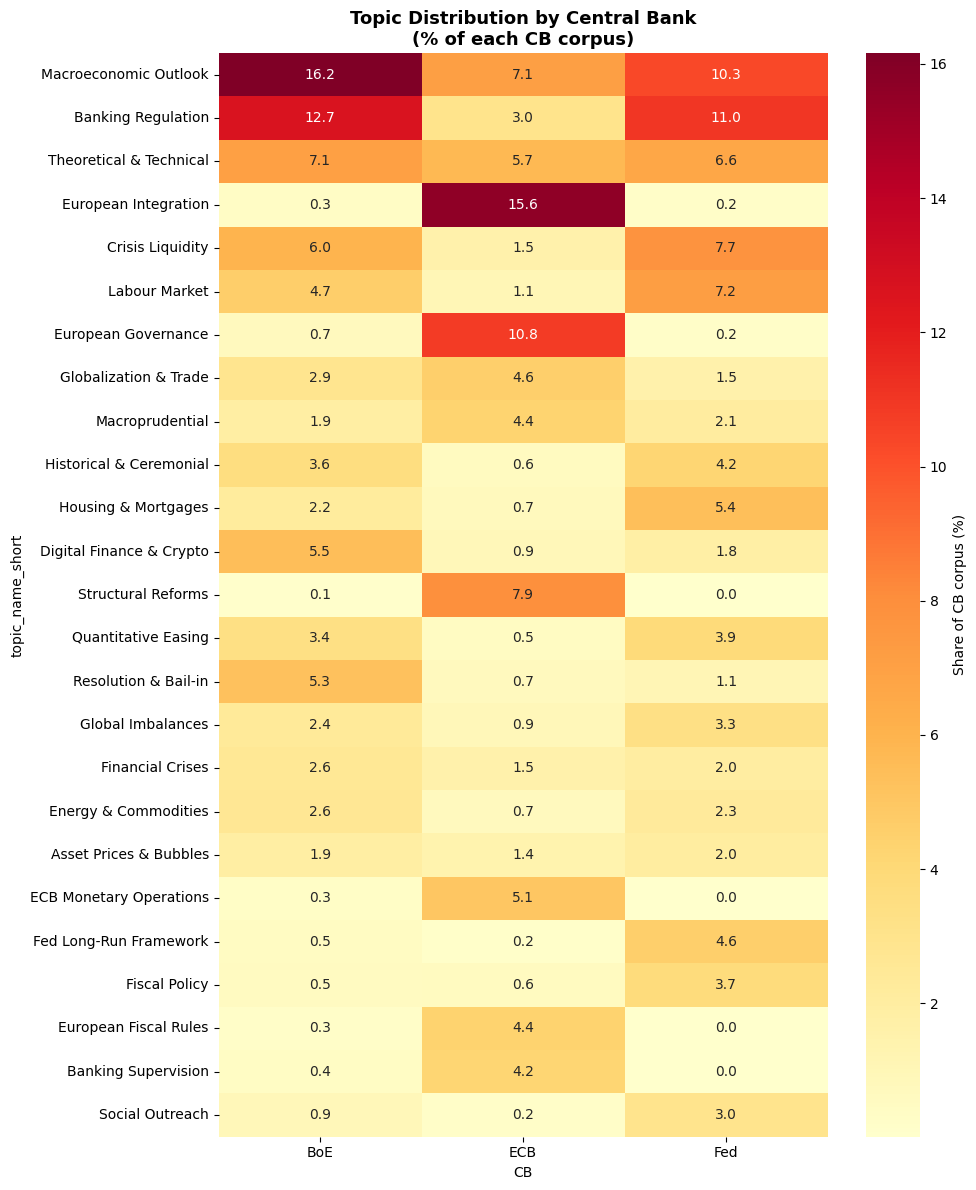

In [29]:
# Rename correctly BEFORE pivoting
cb_name_map = {
    'Bank of England': 'BoE',
    'Board of Governors of the Federal Reserve': 'Fed',
    'European Central Bank': 'ECB'
}
cb_topics['CB'] = cb_topics['CentralBank'].map(cb_name_map)

# Pivot with correct names
heatmap_data = cb_topics.pivot_table(
    index='topic_name_short', 
    columns='CB', 
    values='share', 
    fill_value=0
)

# Force column order
heatmap_data = heatmap_data[['BoE', 'ECB', 'Fed']]

# Sort by total
heatmap_data['total'] = heatmap_data.sum(axis=1)
heatmap_data = heatmap_data.sort_values('total', ascending=False).drop('total', axis=1)
heatmap_data = heatmap_data.head(25)

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt='.1f', 
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Share of CB corpus (%)'}
)
ax.set_title('Topic Distribution by Central Bank\n(% of each CB corpus)', 
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('/home/onyxia/work/nlp_central_banks/lyna_work/figures/heatmap_topics_cb.png',
            dpi=150, bbox_inches='tight')
plt.show()

#### Different treatments of policies by central banks

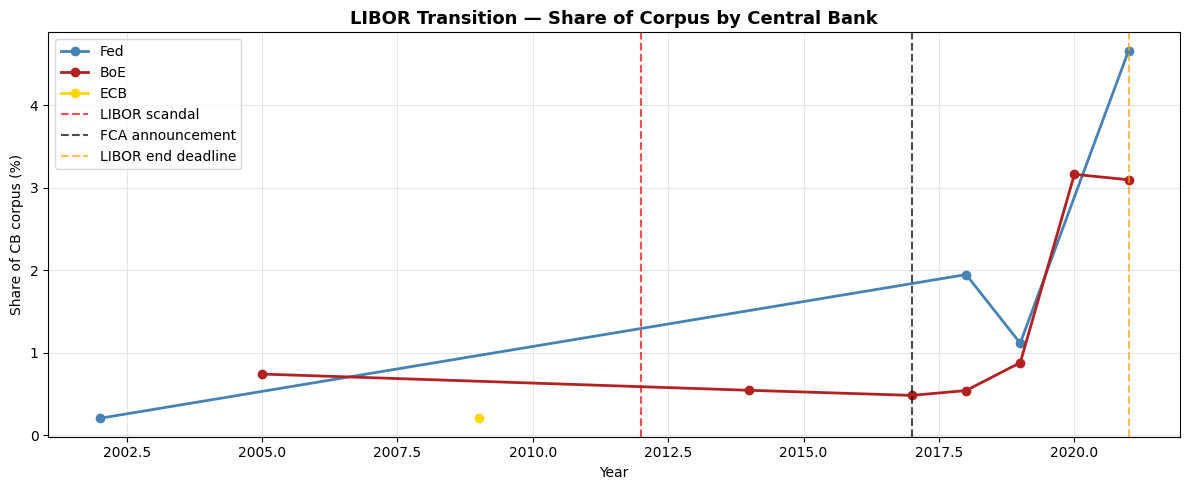

Saved !


In [25]:
# ============================================================
# 4. FOCUS LIBOR — qui en parle en premier ?
# ============================================================

libor_data = (
    df_chunks_all[df_chunks_all['topic'] == 43]
    .groupby(['Year', 'CentralBank'])
    .size()
    .reset_index(name='count')
)
libor_data = libor_data.merge(total_by_cb_year, on=['Year', 'CentralBank'])
libor_data['share'] = libor_data['count'] / libor_data['total'] * 100

fig, ax = plt.subplots(figsize=(12, 5))
for cb in libor_data['CentralBank'].unique():
    data = libor_data[libor_data['CentralBank'] == cb]
    ax.plot(data['Year'], data['share'],
            marker='o', linewidth=2,
            color=cb_colors.get(cb, 'gray'),
            label=cb_labels.get(cb, cb))

ax.axvline(x=2012, color='red', linestyle='--', alpha=0.7, label='LIBOR scandal')
ax.axvline(x=2017, color='black', linestyle='--', alpha=0.7, label='FCA announcement')
ax.axvline(x=2021, color='orange', linestyle='--', alpha=0.7, label='LIBOR end deadline')
ax.set_title('LIBOR Transition — Share of Corpus by Central Bank',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Share of CB corpus (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/home/onyxia/work/nlp_central_banks/lyna_work/figures/libor_by_cb.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved !")

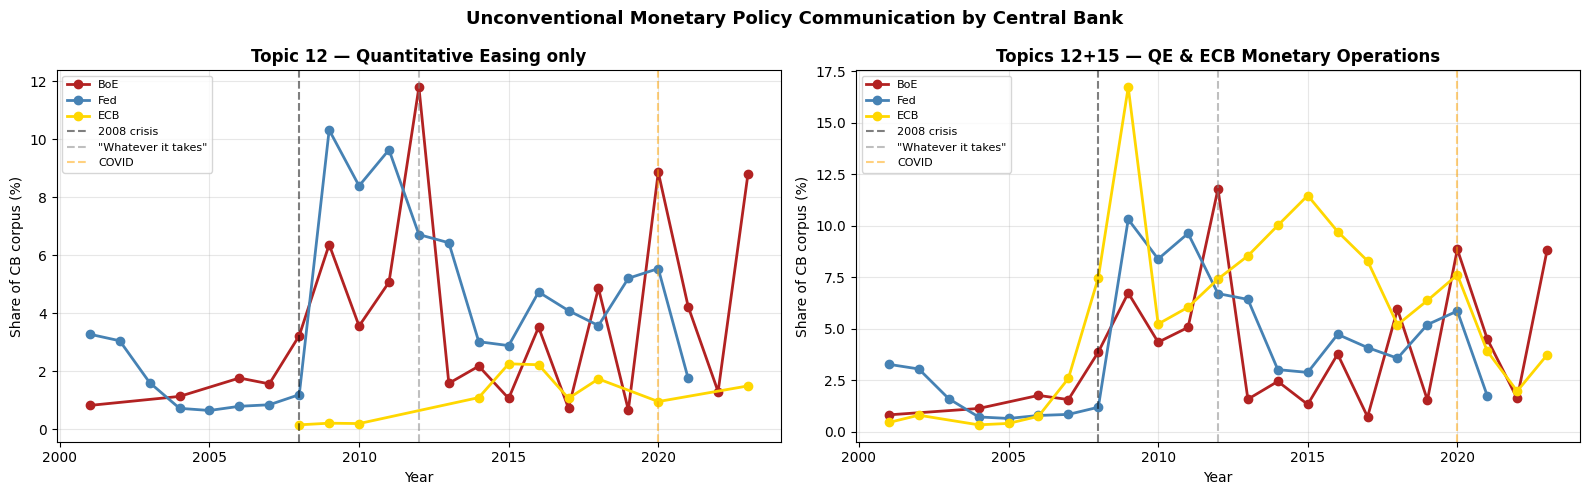

Saved !


In [27]:
# QE + ECB Monetary Operations combined
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1 — QE seul (Topic 12)
for cb in qe_data['CentralBank'].unique():
    data = qe_data[qe_data['CentralBank'] == cb]
    axes[0].plot(data['Year'], data['share'],
                marker='o', linewidth=2,
                color=cb_colors.get(cb, 'gray'),
                label=cb_labels.get(cb, cb))

axes[0].axvline(x=2008, color='black', linestyle='--', alpha=0.5, label='2008 crisis')
axes[0].axvline(x=2012, color='gray', linestyle='--', alpha=0.5, label='"Whatever it takes"')
axes[0].axvline(x=2020, color='orange', linestyle='--', alpha=0.5, label='COVID')
axes[0].set_title('Topic 12 — Quantitative Easing only', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Share of CB corpus (%)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Plot 2 — QE + ECB Monetary Operations (Topic 12 + Topic 15)
combined = (
    df_chunks_all[df_chunks_all['topic'].isin([12, 15])]
    .groupby(['Year', 'CentralBank'])
    .size()
    .reset_index(name='count')
)
combined = combined.merge(total_by_cb_year, on=['Year', 'CentralBank'])
combined['share'] = combined['count'] / combined['total'] * 100

for cb in combined['CentralBank'].unique():
    data = combined[combined['CentralBank'] == cb]
    axes[1].plot(data['Year'], data['share'],
                marker='o', linewidth=2,
                color=cb_colors.get(cb, 'gray'),
                label=cb_labels.get(cb, cb))

axes[1].axvline(x=2008, color='black', linestyle='--', alpha=0.5, label='2008 crisis')
axes[1].axvline(x=2012, color='gray', linestyle='--', alpha=0.5, label='"Whatever it takes"')
axes[1].axvline(x=2020, color='orange', linestyle='--', alpha=0.5, label='COVID')
axes[1].set_title('Topics 12+15 — QE & ECB Monetary Operations', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Share of CB corpus (%)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Unconventional Monetary Policy Communication by Central Bank',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/onyxia/work/nlp_central_banks/lyna_work/figures/qe_combined.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved !")

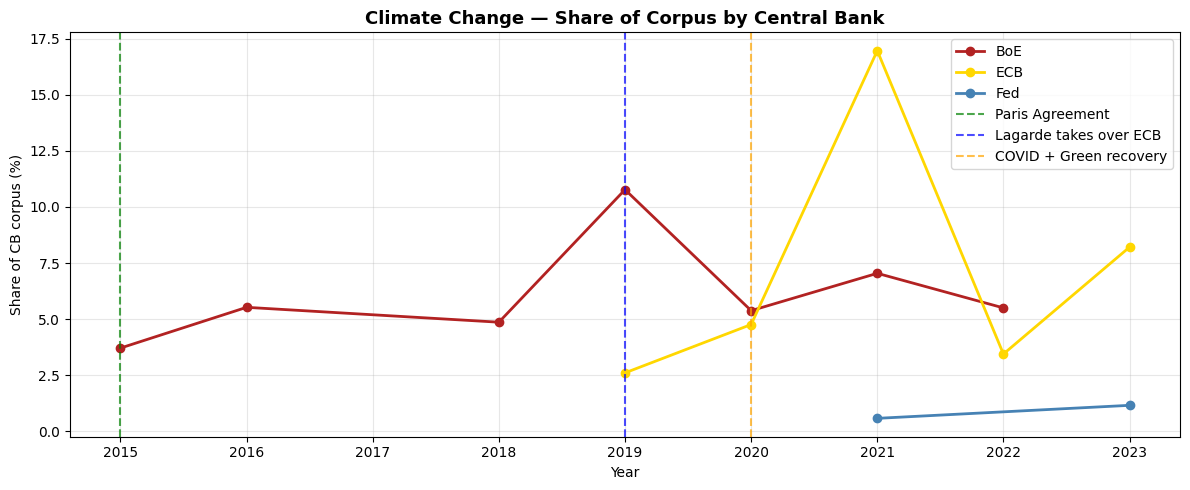

Saved !


In [26]:
# ============================================================
# 5. FOCUS CLIMATE — by CB
# ============================================================

climate_data = (
    df_chunks_all[df_chunks_all['topic'] == 30]
    .groupby(['Year', 'CentralBank'])
    .size()
    .reset_index(name='count')
)
climate_data = climate_data.merge(total_by_cb_year, on=['Year', 'CentralBank'])
climate_data['share'] = climate_data['count'] / climate_data['total'] * 100

fig, ax = plt.subplots(figsize=(12, 5))
for cb in climate_data['CentralBank'].unique():
    data = climate_data[climate_data['CentralBank'] == cb]
    ax.plot(data['Year'], data['share'],
            marker='o', linewidth=2,
            color=cb_colors.get(cb, 'gray'),
            label=cb_labels.get(cb, cb))

ax.axvline(x=2015, color='green', linestyle='--', alpha=0.7, label='Paris Agreement')
ax.axvline(x=2019, color='blue', linestyle='--', alpha=0.7, label='Lagarde takes over ECB')
ax.axvline(x=2020, color='orange', linestyle='--', alpha=0.7, label='COVID + Green recovery')
ax.set_title('Climate Change — Share of Corpus by Central Bank',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Share of CB corpus (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/home/onyxia/work/nlp_central_banks/lyna_work/figures/climate_by_cb.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved !")